# Notebook 06 — Evaluation of Gap Boundary Pipeline

**Pipeline:** Adaptive Classical Vision Pipeline for Rubber Gap Measurement  
**Step 6:** Evaluate the final outputs generated by the current pipeline.

This version is adapted to the final approach:

```text
01_preprocessed
→ 02_rectified
→ 03_canny
→ 04_gap_boundaries
→ 05_metric
→ 06_evaluation
```

The previous `06_evaluation.ipynb` expected Hough lines from `outputs/04_hough/lines.json`.  
That is no longer the main pipeline output, so this notebook evaluates:

- number of detected gaps per image;
- valid/invalid gap measurements;
- recommended gap width in millimetres;
- robust variability of the samples;
- possible problematic images;
- global summary plots and JSON report.

This notebook **does not reprocess images**. It only reads the saved outputs from notebooks 04 and 05.

## 1. Imports and configuration

In [1]:
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
RECTIFIED_DIR = Path("outputs/02_rectified")
GAPS_PATH     = Path("outputs/04_gap_boundaries/gap_boundaries.json")
METRIC_PATH   = Path("outputs/05_metric/measurements.json")

OUTPUT_DIR = Path("outputs/06_evaluation")
DEBUG_DIR  = OUTPUT_DIR / "debug"
PLOTS_DIR  = OUTPUT_DIR / "plots"

for d in [OUTPUT_DIR, DEBUG_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Expected behaviour / quality thresholds ────────────────────────────────
# Most valid images in this dataset contain two relevant gaps.
# If your professor accepts a variable number of gaps, set this to None.
EXPECTED_GAPS_PER_IMAGE = 2

# A gap with too few valid samples is not reliable enough.
MIN_VALID_SAMPLES = 6

# Robust coefficient of variation above this threshold indicates unstable measurements.
MAX_ROBUST_CV = 0.45

# Reasonable measurement interval in mm. This is not a hard physical truth;
# it is used only to flag suspicious values.
MIN_REASONABLE_WIDTH_MM = 1.0
MAX_REASONABLE_WIDTH_MM = 25.0

# Optional: mark images manually known to be problematic after visual inspection.
KNOWN_PROBLEMATIC_IMAGES = {"Multimedia_41.jpg"}

with open(GAPS_PATH, "r") as f:
    gap_results = json.load(f)

with open(METRIC_PATH, "r") as f:
    metric_results = json.load(f)

print(f"Gap results loaded   : {len(gap_results)} images")
print(f"Metric results loaded: {len(metric_results)} images")
print(f"Output dir           : {OUTPUT_DIR.resolve()}")

Gap results loaded   : 20 images
Metric results loaded: 20 images
Output dir           : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\06_evaluation


## 2. Convert results to tabular format

The JSON output is useful for saving the complete structure, but evaluation is easier using flat tables.

In [3]:
def flatten_measurements(metric_results: dict) -> pd.DataFrame:
    rows = []

    for image_name, image_data in metric_results.items():
        image_row_data = {
            "image_name": image_name,
            "px_per_mm": image_data.get("px_per_mm", np.nan),
            "n_gaps": image_data.get("n_gaps", np.nan),
            "n_valid_gaps": image_data.get("n_valid_gaps", np.nan),
            "image_mean_gap_width_mm": image_data.get("image_mean_gap_width_mm", np.nan),
            "image_trimmed_mean_gap_width_mm": image_data.get("image_trimmed_mean_gap_width_mm", np.nan),
            "image_recommended_gap_width_mm": image_data.get("image_recommended_gap_width_mm", np.nan),
            "image_std_gap_width_mm": image_data.get("image_std_gap_width_mm", np.nan),
        }

        for m in image_data.get("measurements", []):
            row = image_row_data.copy()
            row.update({
                "gap_id": m.get("gap_id"),
                "gap_index": m.get("gap_index"),
                "orientation": m.get("orientation"),
                "bbox_x_px": m.get("bbox_x_px", np.nan),
                "bbox_y_px": m.get("bbox_y_px", np.nan),
                "bbox_w_px": m.get("bbox_w_px", np.nan),
                "bbox_h_px": m.get("bbox_h_px", np.nan),
                "area_px": m.get("area_px", np.nan),
                "length_px": m.get("length_px", np.nan),
                "thickness_px": m.get("thickness_px", np.nan),
                "score": m.get("score", np.nan),
                "valid_for_metric": m.get("valid_for_metric", False),
                "n_valid_samples": m.get("n_valid_samples", 0),
                "mean_distance_mm": m.get("mean_distance_mm", np.nan),
                "median_distance_mm": m.get("median_distance_mm", np.nan),
                "trimmed_mean_distance_mm": m.get("trimmed_mean_distance_mm", np.nan),
                "trimmed_std_distance_mm": m.get("trimmed_std_distance_mm", np.nan),
                "std_distance_mm": m.get("std_distance_mm", np.nan),
                "min_distance_mm": m.get("min_distance_mm", np.nan),
                "max_distance_mm": m.get("max_distance_mm", np.nan),
                "range_distance_mm": m.get("range_distance_mm", np.nan),
                "cv_distance": m.get("cv_distance", np.nan),
                "robust_cv_distance": m.get("robust_cv_distance", np.nan),
                "recommended_distance_mm": m.get("recommended_distance_mm", np.nan),
                "n_trimmed_samples": m.get("n_trimmed_samples", np.nan),
            })
            rows.append(row)

    return pd.DataFrame(rows)


def flatten_samples(metric_results: dict) -> pd.DataFrame:
    rows = []

    for image_name, image_data in metric_results.items():
        for m in image_data.get("measurements", []):
            for s in m.get("samples", []):
                rows.append({
                    "image_name": image_name,
                    "gap_id": m.get("gap_id"),
                    "gap_index": m.get("gap_index"),
                    "orientation": m.get("orientation"),
                    "sample_id": s.get("sample_id"),
                    "distance_mm": s.get("distance_mm", np.nan),
                    "used_in_trimmed_mean": s.get("used_in_trimmed_mean", False),
                    "point_a_x_px": s.get("point_a_x_px", np.nan),
                    "point_a_y_px": s.get("point_a_y_px", np.nan),
                    "point_b_x_px": s.get("point_b_x_px", np.nan),
                    "point_b_y_px": s.get("point_b_y_px", np.nan),
                })

    return pd.DataFrame(rows)

measurements_df = flatten_measurements(metric_results)
samples_df = flatten_samples(metric_results)

measurements_df.to_csv(OUTPUT_DIR / "evaluation_measurements_flat.csv", index=False)
samples_df.to_csv(OUTPUT_DIR / "evaluation_samples_flat.csv", index=False)

print(f"Measurements rows: {len(measurements_df)}")
print(f"Samples rows     : {len(samples_df)}")
measurements_df.head()

Measurements rows: 32
Samples rows     : 320


,image_name,px_per_mm,n_gaps,n_valid_gaps,image_mean_gap_width_mm,image_trimmed_mean_gap_width_mm,image_recommended_gap_width_mm,image_std_gap_width_mm,gap_id,gap_index,...,trimmed_mean_distance_mm,trimmed_std_distance_mm,std_distance_mm,min_distance_mm,max_distance_mm,range_distance_mm,cv_distance,robust_cv_distance,recommended_distance_mm,n_trimmed_samples
0,Multimedia_31.jpg,1.0,2,2,6.989680,6.915673,6.915673,0.441470,0,0,...,6.474203,3.419834,4.106362,1.857132,13.857132,12.000000,0.608279,0.528225,6.474203,8
1,Multimedia_31.jpg,1.0,2,2,6.989680,6.915673,6.915673,0.441470,1,1,...,7.357143,2.829320,3.651217,0.857147,12.571426,11.714279,0.505109,0.384568,7.357143,8
2,Multimedia_32.jpg,1.0,2,2,6.129365,6.108135,6.108135,0.137900,0,0,...,5.970235,2.790078,3.630072,0.857147,12.571426,11.714279,0.593242,0.467331,5.970235,8
3,Multimedia_32.jpg,1.0,2,2,6.129365,6.108135,6.108135,0.137900,1,1,...,6.246035,2.300721,3.093493,0.571426,10.857147,10.285721,0.503852,0.368349,6.246035,8
4,Multimedia_33.jpg,1.0,2,2,7.027776,7.079362,7.079362,0.890873,0,0,...,6.188489,3.219980,4.067634,0.857147,13.571442,12.714294,0.636199,0.520318,6.188489,8


## 3. Gap-level quality checks

A gap can be flagged as suspicious when:

- it has too few valid samples;
- its robust variability is too high;
- its recommended distance is outside a reasonable range;
- it is marked as invalid by NB05.

In [4]:
def classify_gap_quality(row: pd.Series) -> tuple[str, list[str]]:
    reasons = []

    if not bool(row.get("valid_for_metric", False)):
        reasons.append("invalid_for_metric")

    if row.get("n_valid_samples", 0) < MIN_VALID_SAMPLES:
        reasons.append("too_few_samples")

    width = row.get("recommended_distance_mm", np.nan)
    if pd.isna(width):
        reasons.append("missing_recommended_width")
    elif width < MIN_REASONABLE_WIDTH_MM or width > MAX_REASONABLE_WIDTH_MM:
        reasons.append("width_out_of_expected_range")

    robust_cv = row.get("robust_cv_distance", np.nan)
    if pd.notna(robust_cv) and robust_cv > MAX_ROBUST_CV:
        reasons.append("high_robust_variability")

    if len(reasons) == 0:
        return "ok", []

    return "warning", reasons

quality = measurements_df.apply(classify_gap_quality, axis=1)
measurements_df["quality_status"] = [q[0] for q in quality]
measurements_df["quality_reasons"] = [";".join(q[1]) for q in quality]

measurements_df.to_csv(OUTPUT_DIR / "evaluation_measurements_with_quality.csv", index=False)

warnings_df = measurements_df[measurements_df["quality_status"] != "ok"].copy()
print(f"Gap warnings: {len(warnings_df)} / {len(measurements_df)}")
warnings_df[["image_name", "gap_id", "orientation", "recommended_distance_mm", "robust_cv_distance", "quality_reasons"]]

Gap warnings: 4 / 32


,image_name,gap_id,orientation,recommended_distance_mm,robust_cv_distance,quality_reasons
0,Multimedia_31.jpg,0,vertical,6.474203,0.528225,high_robust_variability
2,Multimedia_32.jpg,0,vertical,5.970235,0.467331,high_robust_variability
4,Multimedia_33.jpg,0,vertical,6.188489,0.520318,high_robust_variability
20,Multimedia_41.jpg,2,horizontal,6.998030,0.804302,high_robust_variability


## 4. Image-level evaluation

This section aggregates gap-level results by image.

Important note: this is not a classical supervised IoU evaluation, because the final pipeline no longer predicts straight cut-edge masks. It predicts **gap regions and metric distances**. Therefore, this notebook evaluates the quality and consistency of the final measurements.

In [5]:
def image_quality_summary(measurements_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for image_name, group in measurements_df.groupby("image_name"):
        n_gaps = len(group)
        n_ok = int((group["quality_status"] == "ok").sum())
        n_warnings = n_gaps - n_ok

        orientations = group["orientation"].value_counts().to_dict()

        recommended_values = group["recommended_distance_mm"].dropna().values
        robust_cvs = group["robust_cv_distance"].dropna().values

        reasons = []

        if EXPECTED_GAPS_PER_IMAGE is not None and n_gaps != EXPECTED_GAPS_PER_IMAGE:
            reasons.append(f"unexpected_number_of_gaps:{n_gaps}")

        if n_warnings > 0:
            reasons.append(f"gap_quality_warnings:{n_warnings}")

        if image_name in KNOWN_PROBLEMATIC_IMAGES:
            reasons.append("known_problematic_after_visual_inspection")

        rows.append({
            "image_name": image_name,
            "n_detected_gaps": n_gaps,
            "n_ok_gaps": n_ok,
            "n_warning_gaps": n_warnings,
            "n_vertical_gaps": orientations.get("vertical", 0),
            "n_horizontal_gaps": orientations.get("horizontal", 0),
            "image_recommended_gap_width_mm": float(np.mean(recommended_values)) if len(recommended_values) else np.nan,
            "image_std_gap_width_mm": float(np.std(recommended_values)) if len(recommended_values) else np.nan,
            "image_mean_robust_cv": float(np.mean(robust_cvs)) if len(robust_cvs) else np.nan,
            "image_quality_status": "warning" if reasons else "ok",
            "image_quality_reasons": ";".join(reasons),
        })

    return pd.DataFrame(rows).sort_values("image_name")

image_eval_df = image_quality_summary(measurements_df)
image_eval_df.to_csv(OUTPUT_DIR / "image_level_evaluation.csv", index=False)

print(f"Images evaluated: {len(image_eval_df)}")
image_eval_df

Images evaluated: 15


,image_name,n_detected_gaps,n_ok_gaps,n_warning_gaps,n_vertical_gaps,n_horizontal_gaps,image_recommended_gap_width_mm,image_std_gap_width_mm,image_mean_robust_cv,image_quality_status,image_quality_reasons
0,Multimedia_31.jpg,2,1,1,2,0,6.915673,0.441470,0.456396,warning,gap_quality_warnings:1
1,Multimedia_32.jpg,2,1,1,2,0,6.108135,0.137900,0.417840,warning,gap_quality_warnings:1
2,Multimedia_33.jpg,2,1,1,2,0,7.079362,0.890873,0.421203,warning,gap_quality_warnings:1
3,Multimedia_34.jpg,2,2,0,2,0,6.761905,0.672623,0.386631,ok,
4,Multimedia_35.jpg,2,2,0,0,2,10.867076,0.263891,0.134761,ok,
5,Multimedia_36.jpg,2,2,0,0,2,10.867076,0.263891,0.134761,ok,
6,Multimedia_37.jpg,2,2,0,0,2,8.607138,0.605175,0.177034,ok,
7,Multimedia_39.jpg,2,2,0,2,0,7.836309,1.264876,0.219015,ok,
8,Multimedia_40.jpg,2,2,0,2,0,9.214281,1.142862,0.138469,ok,
9,Multimedia_41.jpg,4,3,1,3,1,9.839287,2.337966,0.355372,warning,unexpected_number_of_gaps:4;gap_quality_warnin...


## 5. Aggregate summary

In [6]:
valid_measurements = measurements_df[measurements_df["valid_for_metric"] == True].copy()
ok_measurements = measurements_df[measurements_df["quality_status"] == "ok"].copy()

summary = {
    "n_images_evaluated": int(image_eval_df.shape[0]),
    "n_total_gaps": int(measurements_df.shape[0]),
    "n_valid_metric_gaps": int(valid_measurements.shape[0]),
    "n_ok_quality_gaps": int(ok_measurements.shape[0]),
    "n_gap_warnings": int((measurements_df["quality_status"] != "ok").sum()),
    "n_image_warnings": int((image_eval_df["image_quality_status"] != "ok").sum()),
    "mean_recommended_gap_width_mm_all": float(measurements_df["recommended_distance_mm"].mean()),
    "std_recommended_gap_width_mm_all": float(measurements_df["recommended_distance_mm"].std()),
    "mean_recommended_gap_width_mm_ok_only": float(ok_measurements["recommended_distance_mm"].mean()) if len(ok_measurements) else None,
    "mean_robust_cv_all": float(measurements_df["robust_cv_distance"].mean()),
    "median_robust_cv_all": float(measurements_df["robust_cv_distance"].median()),
    "orientation_counts": measurements_df["orientation"].value_counts().to_dict(),
    "known_problematic_images": sorted(list(KNOWN_PROBLEMATIC_IMAGES)),
}

with open(OUTPUT_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("=" * 60)
print("FINAL EVALUATION SUMMARY")
print("=" * 60)
print(f"Images evaluated        : {summary['n_images_evaluated']}")
print(f"Total gaps detected     : {summary['n_total_gaps']}")
print(f"Valid metric gaps       : {summary['n_valid_metric_gaps']}")
print(f"OK quality gaps         : {summary['n_ok_quality_gaps']}")
print(f"Gap warnings            : {summary['n_gap_warnings']}")
print(f"Image warnings          : {summary['n_image_warnings']}")
print()
print(f"Mean recommended width  : {summary['mean_recommended_gap_width_mm_all']:.2f} mm")
print(f"Std recommended width   : {summary['std_recommended_gap_width_mm_all']:.2f} mm")
if summary['mean_recommended_gap_width_mm_ok_only'] is not None:
    print(f"Mean width, OK only     : {summary['mean_recommended_gap_width_mm_ok_only']:.2f} mm")
print(f"Mean robust CV          : {summary['mean_robust_cv_all']:.3f}")
print(f"Median robust CV        : {summary['median_robust_cv_all']:.3f}")
print(f"Orientation counts      : {summary['orientation_counts']}")
print("=" * 60)

FINAL EVALUATION SUMMARY
Images evaluated        : 15
Total gaps detected     : 32
Valid metric gaps       : 32
OK quality gaps         : 28
Gap warnings            : 4
Image warnings          : 4

Mean recommended width  : 7.52 mm
Std recommended width   : 2.64 mm
Mean width, OK only     : 7.68 mm
Mean robust CV          : 0.269
Median robust CV        : 0.240
Orientation counts      : {'vertical': 19, 'horizontal': 13}


## 6. Plots

C:\Users\david\AppData\Local\Temp\ipykernel_15724\4223246877.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(image_eval_df["image_name"].str.replace(".jpg", "", regex=False), rotation=45, ha="right")


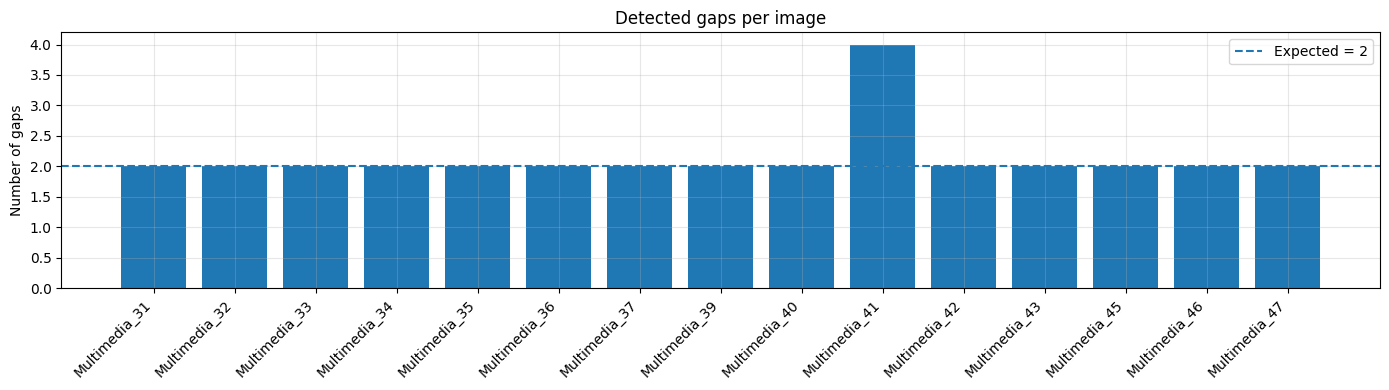

In [7]:
# Plot 1 — number of detected gaps per image
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(image_eval_df["image_name"].str.replace(".jpg", "", regex=False), image_eval_df["n_detected_gaps"])
if EXPECTED_GAPS_PER_IMAGE is not None:
    ax.axhline(EXPECTED_GAPS_PER_IMAGE, linestyle="--", linewidth=1.5, label=f"Expected = {EXPECTED_GAPS_PER_IMAGE}")
ax.set_title("Detected gaps per image")
ax.set_ylabel("Number of gaps")
ax.set_xticklabels(image_eval_df["image_name"].str.replace(".jpg", "", regex=False), rotation=45, ha="right")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "detected_gaps_per_image.png", dpi=150)
plt.show()

C:\Users\david\AppData\Local\Temp\ipykernel_15724\561343217.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df["label"], rotation=70, ha="right", fontsize=8)


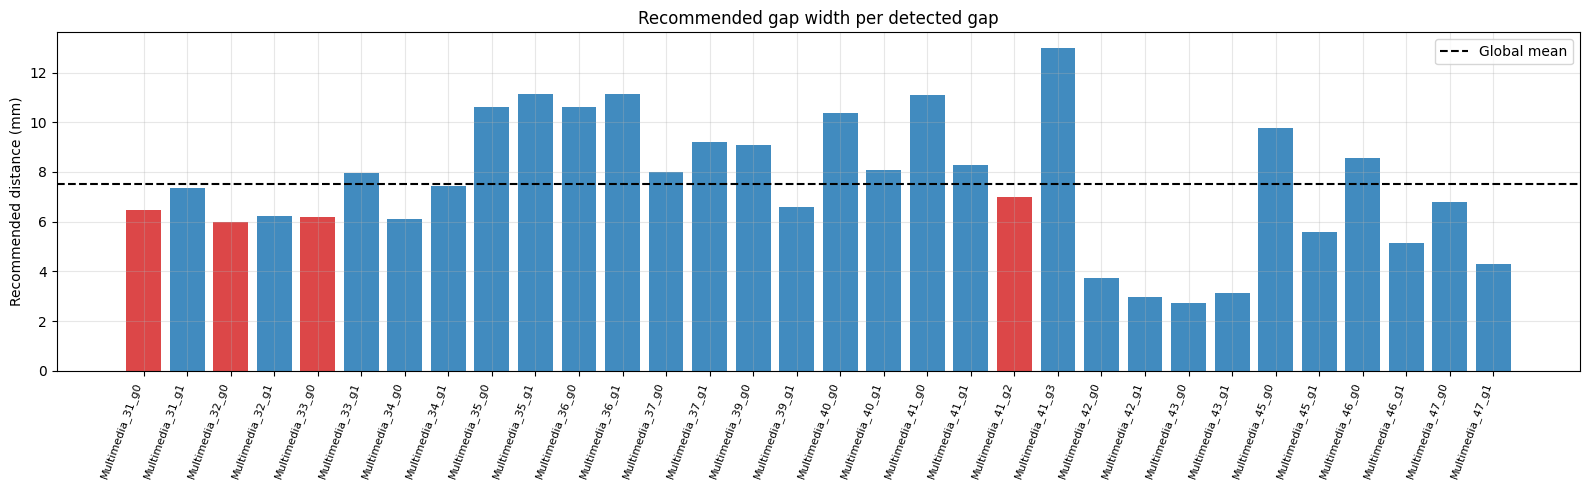

In [8]:
# Plot 2 — recommended gap width per gap
plot_df = measurements_df.copy()
plot_df["label"] = plot_df["image_name"].str.replace(".jpg", "", regex=False) + "_g" + plot_df["gap_index"].astype(str)

fig, ax = plt.subplots(figsize=(16, 5))
colors = np.where(plot_df["quality_status"] == "ok", "tab:blue", "tab:red")
ax.bar(plot_df["label"], plot_df["recommended_distance_mm"], color=colors, alpha=0.85)
ax.axhline(plot_df["recommended_distance_mm"].mean(), linestyle="--", color="black", label="Global mean")
ax.set_title("Recommended gap width per detected gap")
ax.set_ylabel("Recommended distance (mm)")
ax.set_xticklabels(plot_df["label"], rotation=70, ha="right", fontsize=8)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "recommended_gap_widths.png", dpi=150)
plt.show()

C:\Users\david\AppData\Local\Temp\ipykernel_15724\584272440.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df["label"], rotation=70, ha="right", fontsize=8)


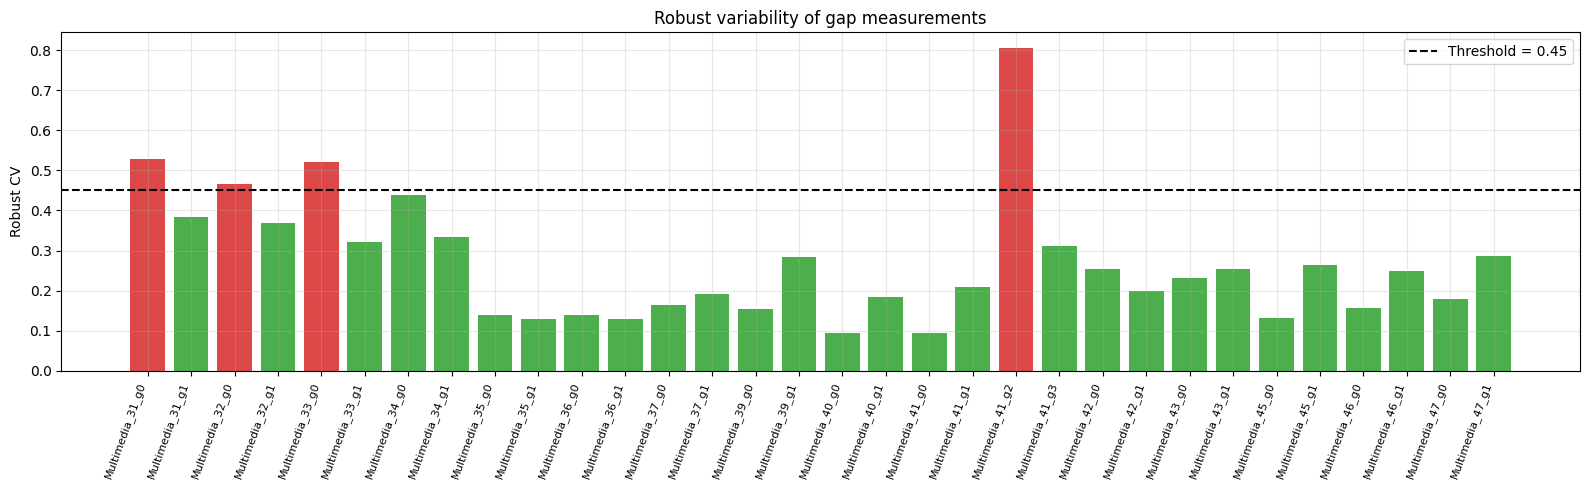

In [9]:
# Plot 3 — robust coefficient of variation
fig, ax = plt.subplots(figsize=(16, 5))
colors = np.where(measurements_df["robust_cv_distance"] <= MAX_ROBUST_CV, "tab:green", "tab:red")
ax.bar(plot_df["label"], measurements_df["robust_cv_distance"], color=colors, alpha=0.85)
ax.axhline(MAX_ROBUST_CV, linestyle="--", color="black", label=f"Threshold = {MAX_ROBUST_CV}")
ax.set_title("Robust variability of gap measurements")
ax.set_ylabel("Robust CV")
ax.set_xticklabels(plot_df["label"], rotation=70, ha="right", fontsize=8)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "robust_cv_per_gap.png", dpi=150)
plt.show()

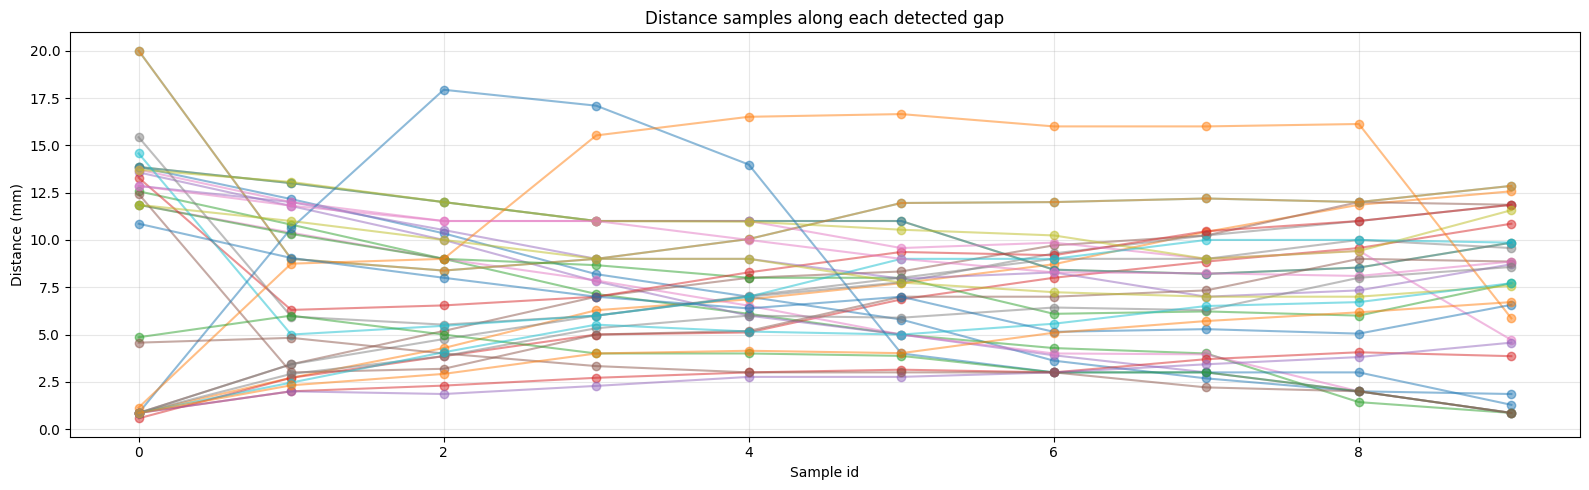

In [10]:
# Plot 4 — sample distances for each gap
fig, ax = plt.subplots(figsize=(16, 5))

for _, row in measurements_df.iterrows():
    image_name = row["image_name"]
    gap_id = row["gap_id"]
    subset = samples_df[(samples_df["image_name"] == image_name) & (samples_df["gap_id"] == gap_id)]
    label = image_name.replace(".jpg", "") + f"_g{gap_id}"
    ax.plot(subset["sample_id"], subset["distance_mm"], marker="o", alpha=0.5, label=label)

ax.set_title("Distance samples along each detected gap")
ax.set_xlabel("Sample id")
ax.set_ylabel("Distance (mm)")
ax.grid(alpha=0.3)
# Avoid huge legend if many gaps
if len(measurements_df) <= 12:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "sample_distances_per_gap.png", dpi=150)
plt.show()

## 7. Optional visual report table

This table is useful for the written report. It keeps one row per image with the main final values.

In [11]:
report_table = image_eval_df[[
    "image_name",
    "n_detected_gaps",
    "n_ok_gaps",
    "n_warning_gaps",
    "n_vertical_gaps",
    "n_horizontal_gaps",
    "image_recommended_gap_width_mm",
    "image_mean_robust_cv",
    "image_quality_status",
    "image_quality_reasons",
]].copy()

report_table["image_recommended_gap_width_mm"] = report_table["image_recommended_gap_width_mm"].round(2)
report_table["image_mean_robust_cv"] = report_table["image_mean_robust_cv"].round(3)

report_table.to_csv(OUTPUT_DIR / "report_table.csv", index=False)
report_table

,image_name,n_detected_gaps,n_ok_gaps,n_warning_gaps,n_vertical_gaps,n_horizontal_gaps,image_recommended_gap_width_mm,image_mean_robust_cv,image_quality_status,image_quality_reasons
0,Multimedia_31.jpg,2,1,1,2,0,6.92,0.456,warning,gap_quality_warnings:1
1,Multimedia_32.jpg,2,1,1,2,0,6.11,0.418,warning,gap_quality_warnings:1
2,Multimedia_33.jpg,2,1,1,2,0,7.08,0.421,warning,gap_quality_warnings:1
3,Multimedia_34.jpg,2,2,0,2,0,6.76,0.387,ok,
4,Multimedia_35.jpg,2,2,0,0,2,10.87,0.135,ok,
5,Multimedia_36.jpg,2,2,0,0,2,10.87,0.135,ok,
6,Multimedia_37.jpg,2,2,0,0,2,8.61,0.177,ok,
7,Multimedia_39.jpg,2,2,0,2,0,7.84,0.219,ok,
8,Multimedia_40.jpg,2,2,0,2,0,9.21,0.138,ok,
9,Multimedia_41.jpg,4,3,1,3,1,9.84,0.355,warning,unexpected_number_of_gaps:4;gap_quality_warnin...


## 8. Final report JSON

In [12]:
final_report = {
    "summary": summary,
    "image_level_evaluation": image_eval_df.to_dict(orient="records"),
    "gap_level_evaluation": measurements_df.to_dict(orient="records"),
}

with open(OUTPUT_DIR / "report.json", "w") as f:
    json.dump(final_report, f, indent=2)

print(f"Final report saved to: {OUTPUT_DIR / 'report.json'}")
print(f"Summary saved to     : {OUTPUT_DIR / 'summary.json'}")
print(f"Plots saved in       : {PLOTS_DIR}")

Final report saved to: outputs\06_evaluation\report.json
Summary saved to     : outputs\06_evaluation\summary.json
Plots saved in       : outputs\06_evaluation\plots


## 9. Interpretation guide

Suggested interpretation for the report:

- The pipeline is evaluated at two levels: image level and gap level.
- The main metric result is `recommended_distance_mm`, based on a robust trimmed mean.
- `robust_cv_distance` measures the stability of the 10 sampled distances along each gap.
- Images with an unexpected number of gaps or high measurement variability are flagged as warnings.
- The current known limitation is that some internal bright artefacts can still be detected as false gaps, especially in difficult images such as `Multimedia_41.jpg`.

This evaluation is more appropriate than the previous Hough-based evaluation because the final pipeline no longer predicts straight lines; it predicts gap regions and distances between their two opposite boundaries.